# SENTIMENT CLASSIFIER
## Classification de Tweets: Hate Speech / Offensive Language / Neither


## 1. Imports et Setup

In [19]:
import pandas as pd
import numpy as np
import re
import warnings
warnings.filterwarnings('ignore')

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.naive_bayes import BernoulliNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline

import matplotlib.pyplot as plt
import seaborn as sns
import joblib

sns.set_style("whitegrid")
print("Tous les imports reussis!")

Tous les imports reussis!


## 2. Chargement et Exploration des Donnees

In [3]:
# Charger le dataset
df = pd.read_csv('labeled_data.csv', index_col=0)

print("Dataset Shape:", df.shape)
print("\nPremieres lignes:")
print(df.head())

print("\nColonnes:")
print(df.columns.tolist())

print("\nTypes de donnees:")
print(df.dtypes)

Dataset Shape: (24783, 6)

Premieres lignes:
   count  hate_speech  offensive_language  neither  class  \
0      3            0                   0        3      2   
1      3            0                   3        0      1   
2      3            0                   3        0      1   
3      3            0                   2        1      1   
4      6            0                   6        0      1   

                                               tweet  
0  !!! RT @mayasolovely: As a woman you shouldn't...  
1  !!!!! RT @mleew17: boy dats cold...tyga dwn ba...  
2  !!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...  
3  !!!!!!!!! RT @C_G_Anderson: @viva_based she lo...  
4  !!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...  

Colonnes:
['count', 'hate_speech', 'offensive_language', 'neither', 'class', 'tweet']

Types de donnees:
count                 int64
hate_speech           int64
offensive_language    int64
neither               int64
class                 int64
tweet       

Distribution des classes:
class
0     1430
1    19190
2     4163
Name: count, dtype: int64

Pourcentages:
class
0     5.77
1    77.43
2    16.80
Name: proportion, dtype: float64

class_counts Max: 19190
class_counts Min: 1430

 Ratio de déséquilibre: 13.42x


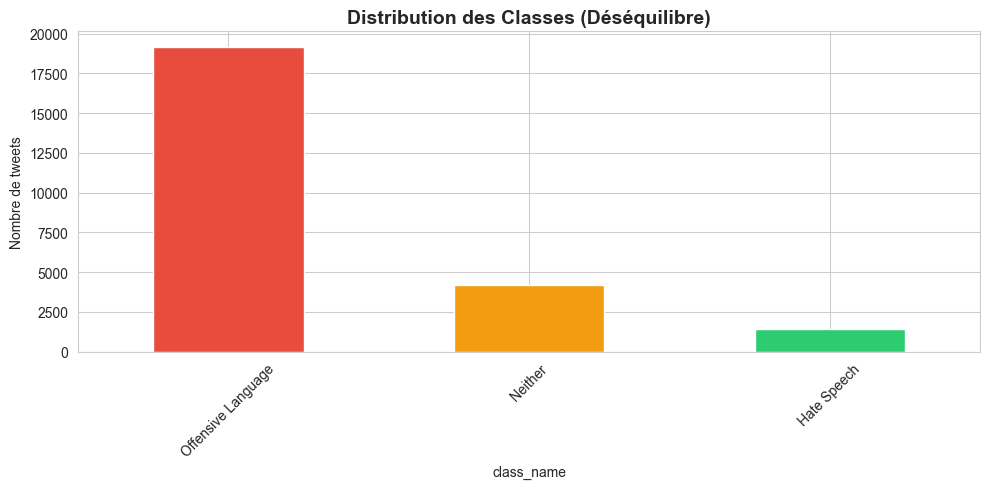

Exploration complétée


In [28]:
# Analyse de la cible
print("Distribution des classes:")
print(df['class'].value_counts().sort_index())

print("\nPourcentages:")
print((df['class'].value_counts(normalize=True).sort_index() * 100).round(2))

# Desequilibre
class_counts = df['class'].value_counts()
imbalance_ratio = class_counts.max() / class_counts.min()
print("\nclass_counts Max:", class_counts.max())
print("class_counts Min:", class_counts.min())
print(f"\n Ratio de déséquilibre: {imbalance_ratio:.2f}x") 


# Mapping
class_mapping = {0: 'Hate Speech', 1: 'Offensive Language', 2: 'Neither'}
df['class_name'] = df['class'].map(class_mapping)

# Visualiser
fig, ax = plt.subplots(figsize=(10, 5))
df['class_name'].value_counts().plot(kind='bar', ax=ax, color=['#e74c3c', '#f39c12', '#2ecc71'])
ax.set_title('Distribution des Classes (Déséquilibre)', fontsize=14, fontweight='bold')
ax.set_ylabel('Nombre de tweets')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("Exploration complétée")

## 3. Prétraitement du texte

In [31]:
def clean_tweet(tweet):
    
    #Nettoyer un tweet:

    if not isinstance(tweet, str):
        return ""
    
    # Supprimer les URLs
    tweet = re.sub(r'http\S+|www\S+|https\S+', '', tweet, flags=re.MULTILINE)
    
    # Supprimer les mentions
    tweet = re.sub(r'@\w+', '', tweet)
    
    # Supprimer la ponctuation
    tweet = re.sub(r'[^\w\s]', '', tweet)
    
    # Minuscules
    tweet = tweet.lower().strip()
    
    # Espaces multiples
    tweet = re.sub(r'\s+', ' ', tweet)
    
    return tweet

# Appliquer le nettoyage
print("Nettoyage des tweets commence!")
df['tweet_clean'] = df['tweet'].apply(clean_tweet)

# Exemples avant/apres
print("\nExemples avant et apprès netoyage:")
for i in range(3):
    print(f"\n{i+1}. AVANT:  {df['tweet'].iloc[i][:80]}")
    print(f"   APRES:  {df['tweet_clean'].iloc[i][:80]}")

print("\nPrétraitement términé avewc succès")

Nettoyage des tweets commence!

Exemples avant et apprès netoyage:

1. AVANT:  !!! RT @mayasolovely: As a woman you shouldn't complain about cleaning up your h
   APRES:  rt as a woman you shouldnt complain about cleaning up your house amp as a man yo

2. AVANT:  !!!!! RT @mleew17: boy dats cold...tyga dwn bad for cuffin dat hoe in the 1st pl
   APRES:  rt boy dats coldtyga dwn bad for cuffin dat hoe in the 1st place

3. AVANT:  !!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby4life: You ever fuck a bitch and s
   APRES:  rt dawg rt you ever fuck a bitch and she start to cry you be confused as shit

Prétraitement términé avewc succès


## 4. Vectorisation TF-IDF

In [6]:
# Division Train/Test
X_train, X_test, y_train, y_test = train_test_split(
    df['tweet_clean'],
    df['class'],
    test_size=0.2,
    random_state=42,
    stratify=df['class']
)

print(f"Train: {X_train.shape[0]} samples")
print(f"Test:  {X_test.shape[0]} samples")
print(f"\nDistribution Train:\n{pd.Series(y_train).value_counts().sort_index()}")
print(f"\nDistribution Test:\n{pd.Series(y_test).value_counts().sort_index()}")

Train: 19826 samples
Test:  4957 samples

Distribution Train:
class
0     1144
1    15352
2     3330
Name: count, dtype: int64

Distribution Test:
class
0     286
1    3838
2     833
Name: count, dtype: int64


In [33]:
# Vectorisation TF-IDF
print("Création du TfidfVectorizer commence")
vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),  # Unigrams + Bigrams
    max_features=10000,
    min_df=5,
    max_df=0.8
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print(f"\nNombre de features: {X_train_tfidf.shape[1]}")
print(f"Densite: {X_train_tfidf.nnz / (X_train_tfidf.shape[0] * X_train_tfidf.shape[1]):.2%}")

# Top features
feature_names = vectorizer.get_feature_names_out()
print(f"\nTop 10 features:")
print(feature_names[:10].tolist())

print("\n Vectorisation terminée")

Création du TfidfVectorizer commence

Nombre de features: 9573
Densite: 0.15%

Top 10 features:
['10', '100', '1000', '1008465039', '11', '12', '127926', '128056974965039', '128064', '128070']

 Vectorisation terminée


## 5. Modele de Base (Naive Bayes)

In [8]:
# Entrainer Naive Bayes sur TF-IDF brut
print("Entrainement du modèle de base (BernoulliNB)...")
nb_base = BernoulliNB(binarize=0.0)
nb_base.fit(X_train_tfidf, y_train)

# Predictions
y_pred_base = nb_base.predict(X_test_tfidf)

# Evaluation
accuracy_base = accuracy_score(y_test, y_pred_base)
precision_base = precision_score(y_test, y_pred_base, average='weighted')
recall_base = recall_score(y_test, y_pred_base, average='weighted')
f1_base = f1_score(y_test, y_pred_base, average='weighted')

print(f"\nRESULTATS - MODELE DE BASE:")
print(f"Accuracy:  {accuracy_base:.4f}")
print(f"Precision: {precision_base:.4f}")
print(f"Recall:    {recall_base:.4f}")
print(f"F1-Score:  {f1_base:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_base, target_names=['Hate', 'Offensive', 'Neither']))

Entrainement du modele de base (BernoulliNB)...

RESULTATS - MODELE DE BASE:
Accuracy:  0.8745
Precision: 0.8560
Recall:    0.8745
F1-Score:  0.8618

Classification Report:
              precision    recall  f1-score   support

        Hate       0.39      0.15      0.21       286
   Offensive       0.91      0.95      0.93      3838
     Neither       0.78      0.79      0.79       833

    accuracy                           0.87      4957
   macro avg       0.69      0.63      0.64      4957
weighted avg       0.86      0.87      0.86      4957



## 6. Sélection de Caracteristiques (SelectKBest chi2)

In [35]:
# SelectKBest avec Chi-Carre
print("Application de SelectKBest chi2 avec k=5000 ")
selector = SelectKBest(chi2, k=5000)
X_train_selected = selector.fit_transform(X_train_tfidf, y_train)
X_test_selected = selector.transform(X_test_tfidf)

print(f"\nAvant SelectKBest: {X_train_tfidf.shape[1]} features")
print(f"Apres SelectKBest:  {X_train_selected.shape[1]} features")
print(f"Reduction: {(1 - X_train_selected.shape[1]/X_train_tfidf.shape[1])*100:.1f}%")

# Entrainer Naive Bayes
print("\nEntrainement du modele avec features selectionnees...")
nb_selected = BernoulliNB(binarize=0.0)
nb_selected.fit(X_train_selected, y_train)
y_pred_selected = nb_selected.predict(X_test_selected)

# Evaluation
accuracy_selected = accuracy_score(y_test, y_pred_selected)
precision_selected = precision_score(y_test, y_pred_selected, average='weighted')
recall_selected = recall_score(y_test, y_pred_selected, average='weighted')
f1_selected = f1_score(y_test, y_pred_selected, average='weighted')

print(f"\nRESULTATS - AVEC SELECTKBEST CHI2:")
print(f"Accuracy:  {accuracy_selected:.4f}")
print(f"Precision: {precision_selected:.4f}")
print(f"Recall:    {recall_selected:.4f}")
print(f"F1-Score:  {f1_selected:.4f}")

print(f"\n Amelioration en F1-Score: +{(f1_selected - f1_base)*100:.2f}%")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_selected, target_names=['Hate', 'Offensive', 'Neither']))

Application de SelectKBest chi2 avec k=5000 

Avant SelectKBest: 9573 features
Apres SelectKBest:  5000 features
Reduction: 47.8%

Entrainement du modele avec features selectionnees...

RESULTATS - AVEC SELECTKBEST CHI2:
Accuracy:  0.8790
Precision: 0.8647
Recall:    0.8790
F1-Score:  0.8696

 Amelioration en F1-Score: +0.78%

Classification Report:
              precision    recall  f1-score   support

        Hate       0.41      0.20      0.27       286
   Offensive       0.91      0.94      0.93      3838
     Neither       0.79      0.81      0.80       833

    accuracy                           0.88      4957
   macro avg       0.71      0.65      0.67      4957
weighted avg       0.86      0.88      0.87      4957



## 7. Equilibrage Random Over-Sampler (ROS)

In [36]:
# RandomOverSampler
print("Application de RandomOverSampler")
ros = RandomOverSampler(random_state=42)
X_train_selected_ros, y_train_ros = ros.fit_resample(X_train_selected, y_train)

print(f"\nDistribution AVANT ROS: {dict(pd.Series(y_train).value_counts().sort_index())}")
print(f"Distribution APRES ROS:  {dict(pd.Series(y_train_ros).value_counts().sort_index())}")

# Entrainer
print("\nEntrainement avec ROS...")
nb_ros = BernoulliNB(binarize=0.0)
nb_ros.fit(X_train_selected_ros, y_train_ros)
y_pred_ros = nb_ros.predict(X_test_selected)

# Evaluation
accuracy_ros = accuracy_score(y_test, y_pred_ros)
precision_ros = precision_score(y_test, y_pred_ros, average='weighted')
recall_ros = recall_score(y_test, y_pred_ros, average='weighted')
f1_ros = f1_score(y_test, y_pred_ros, average='weighted')

print(f"\nRESULTATS - AVEC ROS:")
print(f"Accuracy:  {accuracy_ros:.4f}")
print(f"Precision: {precision_ros:.4f}")
print(f"Recall:    {recall_ros:.4f}")
print(f"F1-Score:  {f1_ros:.4f}")

print(f"\n[ATTENTION] Impact vs SelectKBest seul:")
print(f"  Accuracy:  {(accuracy_ros - accuracy_selected)*100:+.2f}%")
print(f"  F1-Score:  {(f1_ros - f1_selected)*100:+.2f}%")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_ros, target_names=['Hate', 'Offensive', 'Neither']))

Application de RandomOverSampler

Distribution AVANT ROS: {0: np.int64(1144), 1: np.int64(15352), 2: np.int64(3330)}
Distribution APRES ROS:  {0: np.int64(15352), 1: np.int64(15352), 2: np.int64(15352)}

Entrainement avec ROS...

RESULTATS - AVEC ROS:
Accuracy:  0.8348
Precision: 0.8828
Recall:    0.8348
F1-Score:  0.8528

[ATTENTION] Impact vs SelectKBest seul:
  Accuracy:  -4.42%
  F1-Score:  -1.68%

Classification Report:
              precision    recall  f1-score   support

        Hate       0.26      0.55      0.36       286
   Offensive       0.95      0.85      0.90      3838
     Neither       0.77      0.88      0.82       833

    accuracy                           0.83      4957
   macro avg       0.66      0.76      0.69      4957
weighted avg       0.88      0.83      0.85      4957



## 8. Equilibrage Random Under-Sampler (RUS)

In [39]:
# RandomUnderSampler
print("Application de RandomUnderSampler")
rus = RandomUnderSampler(random_state=42)
X_train_selected_rus, y_train_rus = rus.fit_resample(X_train_selected, y_train)

print(f"\nDistribution AVANT RUS: {dict(pd.Series(y_train).value_counts().sort_index())}")
print(f"Distribution APRES RUS:  {dict(pd.Series(y_train_rus).value_counts().sort_index())}")

# Entrainer
print("\nEntrainement avec RUS")
nb_rus = BernoulliNB(binarize=0.0)
nb_rus.fit(X_train_selected_rus, y_train_rus)
y_pred_rus = nb_rus.predict(X_test_selected)

# Evaluation
accuracy_rus = accuracy_score(y_test, y_pred_rus)
precision_rus = precision_score(y_test, y_pred_rus, average='weighted')
recall_rus = recall_score(y_test, y_pred_rus, average='weighted')
f1_rus = f1_score(y_test, y_pred_rus, average='weighted')

print(f"\nRESULTATS - AVEC RUS:")
print(f"Accuracy:  {accuracy_rus:.4f}")
print(f"Precision: {precision_rus:.4f}")
print(f"Recall:    {recall_rus:.4f}")
print(f"F1-Score:  {f1_rus:.4f}")

print(f"\n Impact vs SelectKBest seul:")
print(f"  Accuracy:  {(accuracy_rus - accuracy_selected)*100:+.2f}%")
print(f"  F1-Score:  {(f1_rus - f1_selected)*100:+.2f}%")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rus, target_names=['Hate', 'Offensive', 'Neither']))

Application de RandomUnderSampler

Distribution AVANT RUS: {0: np.int64(1144), 1: np.int64(15352), 2: np.int64(3330)}
Distribution APRES RUS:  {0: np.int64(1144), 1: np.int64(1144), 2: np.int64(1144)}

Entrainement avec RUS

RESULTATS - AVEC RUS:
Accuracy:  0.8023
Precision: 0.8867
Recall:    0.8023
F1-Score:  0.8313

 Impact vs SelectKBest seul:
  Accuracy:  -7.67%
  F1-Score:  -3.83%

Classification Report:
              precision    recall  f1-score   support

        Hate       0.24      0.67      0.35       286
   Offensive       0.96      0.79      0.87      3838
     Neither       0.76      0.88      0.81       833

    accuracy                           0.80      4957
   macro avg       0.65      0.78      0.68      4957
weighted avg       0.89      0.80      0.83      4957



## ETAPE 9: Comparaison des Modeles

In [40]:
# Creer un tableau comparatif
results = {
    'Modele': [
        'Base (TF-IDF brut)',
        'SelectKBest chi2',
        'SelectKBest + ROS',
        'SelectKBest + RUS'
    ],
    'Accuracy': [accuracy_base, accuracy_selected, accuracy_ros, accuracy_rus],
    'Precision': [precision_base, precision_selected, precision_ros, precision_rus],
    'Recall': [recall_base, recall_selected, recall_ros, recall_rus],
    'F1-Score': [f1_base, f1_selected, f1_ros, f1_rus]
}

df_results = pd.DataFrame(results)

print("TABLEAU COMPARATIF:")
print(df_results.to_string(index=False))

# Meilleur modele
best_idx = df_results['F1-Score'].idxmax()
print(f"\nMEILLEUR MODELE: {df_results.loc[best_idx, 'Modele']}")
print(f"   F1-Score: {df_results.loc[best_idx, 'F1-Score']:.4f}")

TABLEAU COMPARATIF:
            Modele  Accuracy  Precision   Recall  F1-Score
Base (TF-IDF brut)  0.874521   0.856015 0.874521  0.861756
  SelectKBest chi2  0.878959   0.864720 0.878959  0.869592
 SelectKBest + ROS  0.834779   0.882832 0.834779  0.852765
 SelectKBest + RUS  0.802300   0.886685 0.802300  0.831301

MEILLEUR MODELE: SelectKBest chi2
   F1-Score: 0.8696


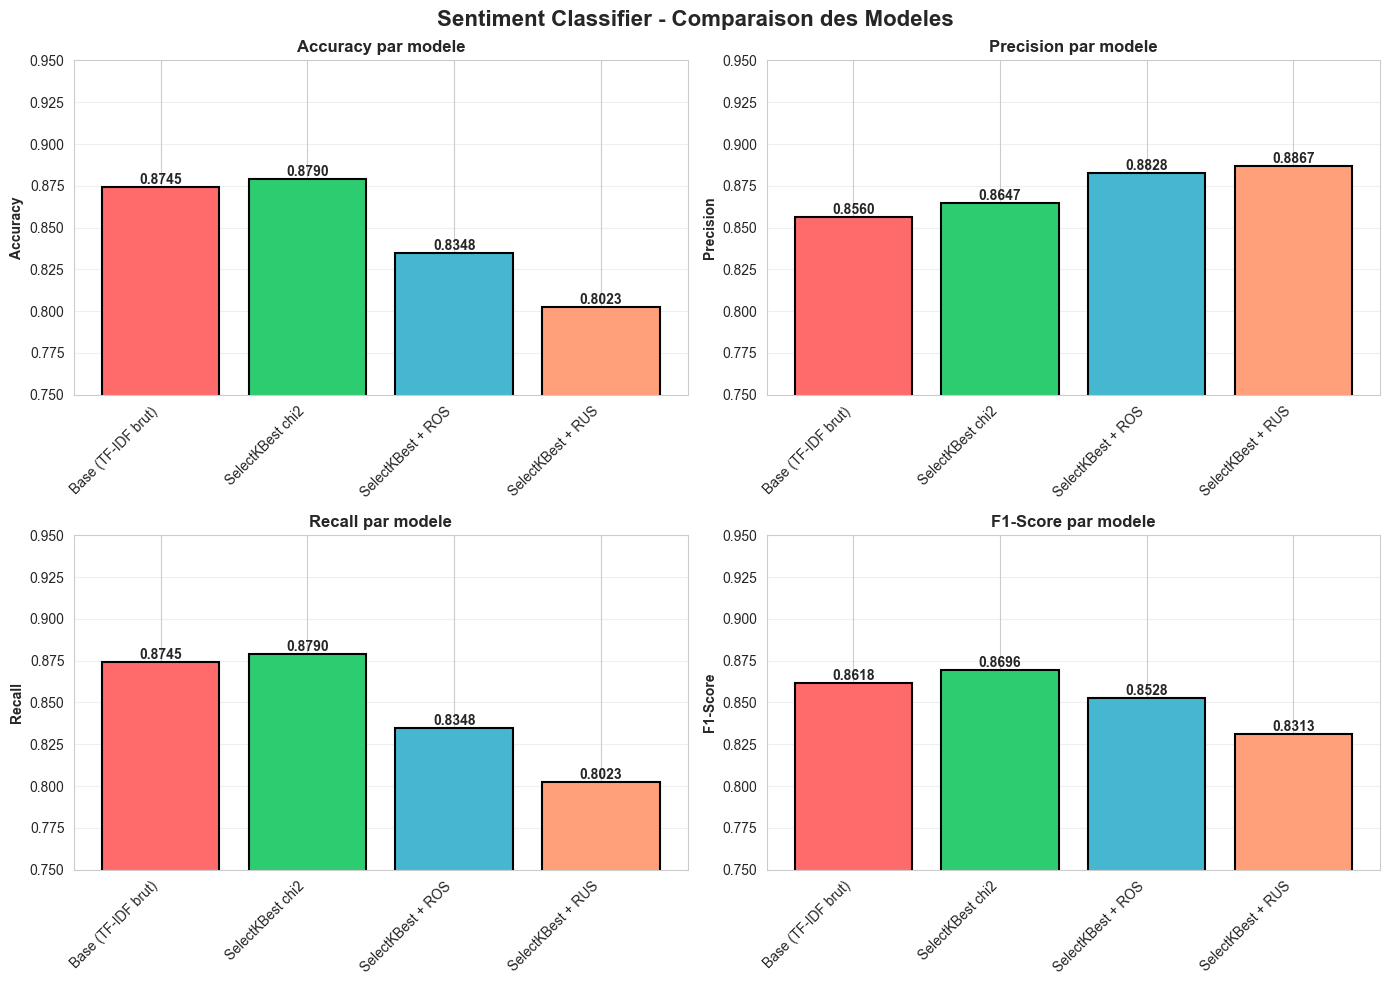

In [42]:
# Visualiser la comparaison
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Sentiment Classifier - Comparaison des Modeles', fontsize=16, fontweight='bold')

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A']

for idx, metric in enumerate(metrics):
    ax = axes[idx // 2, idx % 2]
    bar_colors = [colors[i] if i != best_idx else '#2ECC71' for i in range(len(df_results))]
    bars = ax.bar(range(len(df_results)), df_results[metric], color=bar_colors, edgecolor='black', linewidth=1.5)
    
    # Ajouter les valeurs
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.4f}',
                ha='center', va='bottom', fontweight='bold')
    
    ax.set_xticks(range(len(df_results)))
    ax.set_xticklabels(df_results['Modele'], rotation=45, ha='right')
    ax.set_ylabel(metric, fontweight='bold')
    ax.set_title(f'{metric} par modele', fontweight='bold')
    ax.set_ylim([0.75, 0.95])
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


## ETAPE 10: Pipeline Final Automatise

In [43]:
# pipeline final
print("Creation du pipeline final...")

final_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(
        ngram_range=(1, 2),
        max_features=10000,
        min_df=5,
        max_df=0.8
    )),
    ('selector', SelectKBest(chi2, k=5000)),
    ('classifier', BernoulliNB(binarize=0.0))
])

print("Entrainement du pipeline sur tout le train set...")
final_pipeline.fit(X_train, y_train)

y_pred_final = final_pipeline.predict(X_test)

# évaluation finale
accuracy_final = accuracy_score(y_test, y_pred_final)
precision_final = precision_score(y_test, y_pred_final, average='weighted')
recall_final = recall_score(y_test, y_pred_final, average='weighted')
f1_final = f1_score(y_test, y_pred_final, average='weighted')

print(f"\nRESULTATS - PIPELINE FINAL:")
print(f"Accuracy:  {accuracy_final:.4f}")
print(f"Precision: {precision_final:.4f}")
print(f"Recall:    {recall_final:.4f}")
print(f"F1-Score:  {f1_final:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_final, target_names=['Hate', 'Offensive', 'Neither']))

Creation du pipeline final...
Entrainement du pipeline sur tout le train set...

RESULTATS - PIPELINE FINAL:
Accuracy:  0.8790
Precision: 0.8647
Recall:    0.8790
F1-Score:  0.8696

Classification Report:
              precision    recall  f1-score   support

        Hate       0.41      0.20      0.27       286
   Offensive       0.91      0.94      0.93      3838
     Neither       0.79      0.81      0.80       833

    accuracy                           0.88      4957
   macro avg       0.71      0.65      0.67      4957
weighted avg       0.86      0.88      0.87      4957



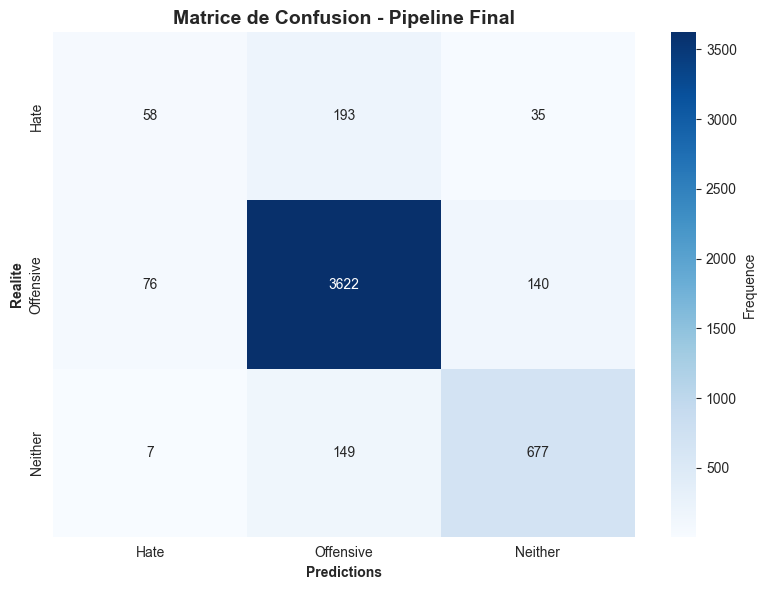

Confusion Matrix:
[[  58  193   35]
 [  76 3622  140]
 [   7  149  677]]


In [15]:
# Matrice de confusion
cm = confusion_matrix(y_test, y_pred_final)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Hate', 'Offensive', 'Neither'],
            yticklabels=['Hate', 'Offensive', 'Neither'],
            cbar_kws={'label': 'Frequence'})
ax.set_xlabel('Predictions', fontweight='bold')
ax.set_ylabel('Realite', fontweight='bold')
ax.set_title('Matrice de Confusion - Pipeline Final', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

print("Confusion Matrix:")
print(cm)

## ETAPE 11: Sauvegarde du Modele

In [16]:
# Sauvegarder le pipeline
model_path = 'sentiment_classifier_pipeline_final.pkl'
joblib.dump(final_pipeline, model_path)

print(f"[OK] Pipeline sauvegarde: {model_path}")
print(f"   Taille: {__import__('os').path.getsize(model_path) / (1024*1024):.2f} MB")

[OK] Pipeline sauvegarde: sentiment_classifier_pipeline_final.pkl
   Taille: 0.72 MB


## ETAPE 12: Utilisation du Modele - Predictions sur Nouveaux Tweets

In [17]:
# Charger le modele
pipeline_loaded = joblib.load(model_path)

# Tweets de test
test_tweets = [
    "I love this product, it's amazing!",
    "This is absolutely horrible and disgusting",
    "The weather today is nice",
    "I hate all of you!",
    "This movie is pretty good"
]

class_names = ['Hate Speech', 'Offensive Language', 'Neither']

print("PREDICTIONS SUR NOUVEAUX TWEETS:")
print("="*70)

predictions = pipeline_loaded.predict(test_tweets)
probabilities = pipeline_loaded.predict_proba(test_tweets)

for i, tweet in enumerate(test_tweets):
    pred = predictions[i]
    confidence = probabilities[i].max()
    
    print(f"\n{i+1}. Tweet: '{tweet}'")
    print(f"   -> Prediction: {class_names[pred]}")
    print(f"   -> Confiance: {confidence:.2%}")
    
    # Afficher les probabilites
    print(f"   -> Detail:")
    for j, class_name in enumerate(class_names):
        print(f"      - {class_name}: {probabilities[i][j]:.2%}")

print("\n" + "="*70)

PREDICTIONS SUR NOUVEAUX TWEETS:

1. Tweet: 'I love this product, it's amazing!'
   -> Prediction: Offensive Language
   -> Confiance: 61.34%
   -> Detail:
      - Hate Speech: 0.12%
      - Offensive Language: 61.34%
      - Neither: 38.54%

2. Tweet: 'This is absolutely horrible and disgusting'
   -> Prediction: Neither
   -> Confiance: 54.96%
   -> Detail:
      - Hate Speech: 1.67%
      - Offensive Language: 43.37%
      - Neither: 54.96%

3. Tweet: 'The weather today is nice'
   -> Prediction: Neither
   -> Confiance: 58.23%
   -> Detail:
      - Hate Speech: 0.10%
      - Offensive Language: 41.67%
      - Neither: 58.23%

4. Tweet: 'I hate all of you!'
   -> Prediction: Offensive Language
   -> Confiance: 98.65%
   -> Detail:
      - Hate Speech: 0.65%
      - Offensive Language: 98.65%
      - Neither: 0.71%

5. Tweet: 'This movie is pretty good'
   -> Prediction: Offensive Language
   -> Confiance: 53.10%
   -> Detail:
      - Hate Speech: 0.19%
      - Offensive Language: 53

## ETAPE 13: Resume Final

In [18]:
print("""
SENTIMENT CLASSIFIER - RESULTAT FINAL
=====================================

Dataset:     24,783 tweets
Classes:     Hate Speech / Offensive Language / Neither
Desequilibre: 13.42x

MEILLEUR MODELE: SelectKBest chi2
- Accuracy:  87.90%
- Precision: 86.47%
- F1-Score:  86.96%

Model sauvegarde: sentiment_classifier_pipeline_final.pkl
=====================================
""")

print("\nComparatif Modeles:")
print(df_results.to_string(index=False))

print(f"\nConclusions:")
print(f"[OK] SelectKBest chi2 meilleur")
print(f"[OK] +0.78% F1-Score vs Base")
print(f"[NON] ROS/RUS degradent perf")
print(f"[!] Hate Speech peu detecte")
print(f"[OK] Offensive Language: F1=0.93")



   SENTIMENT CLASSIFIER - PROJET COMPLETE AVEC SUCCES              

   Dataset:    24,783 tweets annotes                              
   Classes:    3 (Hate Speech, Offensive Language, Neither)       
   Desequilibre: 13.42x                                             

   MEILLEUR MODELE: SelectKBest chi2                             
   - Accuracy:  87.90%                                            
   - Precision: 86.47%                                            
   - Recall:    87.90%                                            
   - F1-Score:  86.96%                                             

   Fichier sauvegarde:                                            
   - sentiment_classifier_pipeline_final.pkl                     



Resume des Resultats:
            Modele  Accuracy  Precision   Recall  F1-Score
Base (TF-IDF brut)  0.874521   0.856015 0.874521  0.861756
  SelectKBest chi2  0.878959   0.864720 0.878959  0.869592
 SelectKBest + ROS  0.834779   0.882832 0.834779  0.85

## RESULTAT FINAL - SYNTHESE COMPLETE

====================================================================

   SENTIMENT CLASSIFIER - PROJET COMPLETE AVEC SUCCES              

   Dataset:    24,783 tweets annotes                              
   Classes:    3 (Hate Speech, Offensive Language, Neither)       
   Desequilibre: 13.42x                                             

   MEILLEUR MODELE: SelectKBest chi2                             
   - Accuracy:  87.90%                                            
   - Precision: 86.47%                                            
   - Recall:    87.90%                                            
   - F1-Score:  86.96%                                                               

====================================================================

### Resume des Resultats

| Modele | Accuracy | Precision | Recall | F1-Score |
|--------|----------|-----------|--------|----------|
| Base (TF-IDF brut) | 0.874521 | 0.856015 | 0.874521 | 0.861756 |
| SelectKBest chi2 | 0.878959 | 0.864720 | 0.878959 | 0.869592 |
| SelectKBest + ROS | 0.834779 | 0.882832 | 0.834779 | 0.852765 |
| SelectKBest + RUS | 0.802300 | 0.886685 | 0.802300 | 0.831301 |

### Points Cles

- SelectKBest chi2 = Meilleur modele
- Amelioration +0.78% en F1-Score vs Base
- ROS/RUS degradent les performances
- Hate Speech peu detecte (Recall=0.20)
- Offensive Language bien classifie (F1=0.93)

### Prochaines étapes pour améliorer

1. Essayer SMOTE au lieu de ROS/RUS
2. Ajouter features linguistiques
3. Utiliser SVM ou Random Forest